In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

In [28]:
ROOT_DIR = Path.cwd()
ss = ROOT_DIR/'data'/'superstoreSales.csv'
df = pd.read_csv(ss)

How have total monthly sales changed over the years? Show a monthly line with
a 3-month moving average (Modules 13–14).

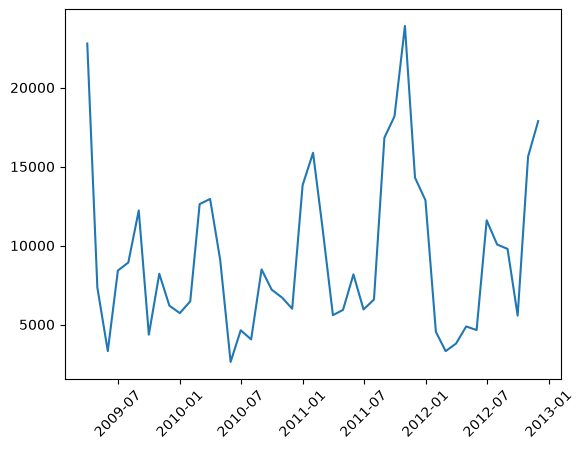

In [16]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
monthly = df.set_index('Order Date')['Sales'].resample('ME').sum()
monthly = monthly.rolling(3).mean()

plt.plot(monthly.index, monthly.values)
plt.tick_params(axis='x', rotation=45)
plt.savefig('monthly.png')

Build a Region × Product Category grid of total sales, and identify the
strongest region–category combination (Modules 11–12).

In [17]:
df = df.groupby(['Region', 'Product Category'])['Sales'].sum()
df = df.sort_values(ascending=False)
df

Region                 Product Category
Northwest Territories  Furniture           156267.3460
                       Technology          130991.7385
                       Office Supplies      67643.0700
Nunavut                Furniture            43545.6140
                       Office Supplies      38615.4700
                       Technology           34215.3995
Name: Sales, dtype: float64

In [18]:
df = df.xs('Furniture', level='Product Category')

In [19]:
cus = ROOT_DIR/'data'/'customers.csv'
ord = ROOT_DIR/'data'/'orders.csv'

dfo = pd.read_csv(ord)
dfc = pd.read_csv(cus)

Using orders.csv + customers.csv , merge and find the top-spending
customers, verifying the join with validate and indicator (Module 16).

In [20]:
print(f'custmers dataset: {dfc.columns}')
print(f'orders dataset: {dfo.columns}')

custmers dataset: Index(['customer_id', 'name', 'city', 'segment'], dtype='str')
orders dataset: Index(['order_id', 'customer_id', 'product', 'quantity', 'price',
       'order_date'],
      dtype='str')


In [21]:
merged = pd.merge(dfc, dfo, on='customer_id', how='inner', indicator=True, validate='many_to_many')
merged.to_csv('merged.csv', index=False)

In [22]:
merged['total_spent'] = merged['price'] * merged['quantity']
grouped = merged.groupby('name')['total_spent'].sum()
grouped.to_csv('top_customer.csv')

In [23]:
df = df.reset_index()

In [29]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Order Priority', 'Order Quantity',
       'Sales', 'Discount', 'Ship Mode', 'Profit', 'Unit Price',
       'Shipping Cost', 'Customer Name', 'Province', 'Region',
       'Customer Segment', 'Product Category', 'Product Sub-Category',
       'Product Name', 'Product Container', 'Product Base Margin',
       'Ship Date'],
      dtype='str')


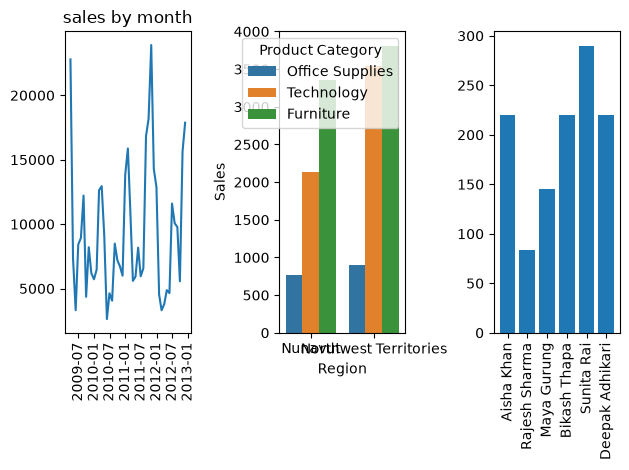

In [32]:
fig, axes = plt.subplots(1,3)
x = [1,2,3]
y=[1,2,3]

axes[0].plot(monthly.index, monthly.values)
axes[0].tick_params(axis='x', rotation=90)
axes[0].set_title('sales by month')

sns.barplot(data= df, x= 'Region', y='Sales', hue= 'Product Category', ax= axes[1], errorbar=None)

axes[2].bar(merged['name'], merged['total_spent'])
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.savefig('summary.png')

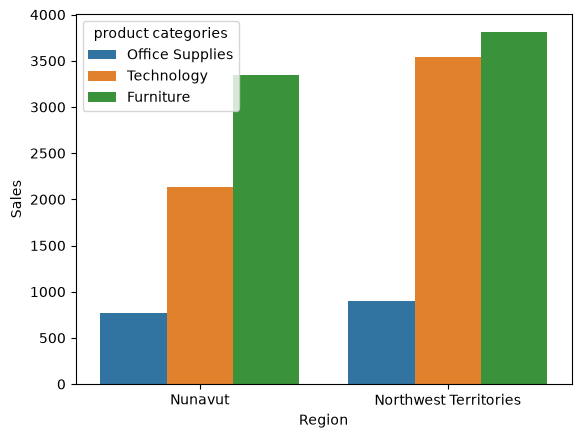

In [12]:
sns.barplot(data=df, x= df['Region'], y=df['Sales'], hue='Product Category', errorbar=None)
plt.legend(title='product categories')